# House Price — Étude Systématique du Prétraitement

Le prétraitement actuel (médiane + RobustScaler + OneHotEncoder) est générique.  
Ce notebook teste **6 axes d'amélioration** en isolation puis les combine.

| Axe | Problème actuel | Solution testée |
|-----|----------------|-----------------|
| 1. Valeurs manquantes sémantiques | NaN = absent traité comme "inconnu" | Imputation contextuelle (NaN garage → 0) |
| 2. Outliers | Aucun traitement explicite | Winsorizing IQR + filtre ventes atypiques |
| 3. Asymétrie des features | Distributions skewed non corrigées | Yeo-Johnson sur features numériques |
| 4. Variables ordinales | OneHot sur `ExterQual`, `KitchenQual`... | OrdinalEncoder avec ordre métier |
| 5. Haute cardinalité | OneHot sur `Neighborhood` | TargetEncoder |
| 6. Feature interactions | Aucune | Produits croisés key features |

**Protocole** : cross-validation 5-fold, RMSE en dollars, modèle LightGBM (meilleur du benchmark).

In [1]:
import sys, warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
from loguru import logger

from scipy.stats import skew

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose  import ColumnTransformer
from sklearn.impute   import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import (RobustScaler, StandardScaler,
                                    OrdinalEncoder, OneHotEncoder,
                                    PowerTransformer, FunctionTransformer)
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor

import ppscore as pps
from category_encoders import TargetEncoder

sys.path.append(str(Path.cwd().parent))
from settings.params import MODEL_PARAMS, SEED
from src.make_dataset import load_data

TARGET = MODEL_PARAMS["TARGET"]
N_FOLDS = 5
SEED    = 43

# Best LightGBM params (Optuna)
BEST_LGBM = dict(n_estimators=845, learning_rate=0.02114, num_leaves=180,
                  max_depth=6, min_child_samples=13, subsample=0.7182,
                  colsample_bytree=0.5100, reg_alpha=0.1073, reg_lambda=0.00850,
                  random_state=SEED, verbose=-1, n_jobs=-1)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
logger.info("Imports OK")

2026-06-08 12:29:52.360 | INFO     | __main__:<module>:44 - Imports OK


## 1. Chargement & diagnostic du prétraitement actuel

In [2]:
raw = load_data(dataset_name="house_prices", columns_to_lower=True)
raw = raw.astype({
    "overallqual": str, "overallcond": str, "garageyrblt": str,
    "yearbuilt": str, "yearremodadd": str, "mssubclass": str,
    "mosold": str, "yrsold": str,
})

logger.info(f"Dataset : {raw.shape[0]} lignes × {raw.shape[1]} colonnes")

# ── Diagnostic : asymétrie des features numériques ────────────────────────
num_cols = raw.select_dtypes(include="number").columns.tolist()
num_cols = [c for c in num_cols if c != TARGET]

skewness = raw[num_cols].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
print("── Top 15 features les plus asymétriques (|skew| > 0.75) ──")
print(skewness[skewness.abs() > 0.75].head(20).to_string())

2026-06-08 12:29:52.382 | INFO     | src.make_dataset:load_data:31 - Loaded house_prices dataset


2026-06-08 12:29:52.382 | INFO     | src.make_dataset:load_data:32 - dataset description : Ask a home buyer to describe their dream house, and they probably won't begin with the height of the basement ceiling or the proximity to an east-west railroad. But this playground competition's dataset proves that much more influences price negotiations than the number of bedrooms or a white-picket fence.

With 79 explanatory variables describing (almost) every aspect of residential homes in Ames, Iowa, this competition challenges you to predict the final price of each home.

MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
  

2026-06-08 12:29:52.383 | INFO     | src.make_dataset:load_data:33 - Data Shape: (1460, 84)


2026-06-08 12:29:52.389 | INFO     | __main__:<module>:8 - Dataset : 1460 lignes × 84 colonnes


── Top 15 features les plus asymétriques (|skew| > 0.75) ──
miscval         24.45
poolarea        14.81
lotarea         12.20
3ssnporch       10.29
lowqualfinsf     9.00
kitchenabvgr     4.48
bsmtfinsf2       4.25
screenporch      4.12
bsmthalfbath     4.10
enclosedporch    3.09
masvnrarea       2.67
openporchsf      2.36
lotfrontage      2.16
bsmtfinsf1       1.68
wooddecksf       1.54
totalbsmtsf      1.52
1stflrsf         1.38
grlivarea        1.37
bsmtunfsf        0.92
2ndflrsf         0.81


In [3]:
# ── Diagnostic : valeurs manquantes sémantiques ──────────────────────────
missing = raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("── Valeurs manquantes (> 0) ──")
print(missing.head(25).to_string())

# Variables connues comme "manquantes sémantiques" dans Ames Housing
SEMANTIC_MISSING = {
    # Variable      → valeur de remplacement (signifie "absent")
    "poolqc":        "NoPool",
    "alley":         "NoAlley",
    "fence":         "NoFence",
    "miscfeature":   "NoMisc",
    "fireplacequ":   "NoFireplace",
    "garagetype":    "NoGarage",
    "garagefinish":  "NoGarage",
    "garagequal":    "NoGarage",
    "garagecond":    "NoGarage",
    "bsmtqual":      "NoBsmt",
    "bsmtcond":      "NoBsmt",
    "bsmtexposure":  "NoBsmt",
    "bsmtfintype1":  "NoBsmt",
    "bsmtfintype2":  "NoBsmt",
    "masvnrtype":    "None",
}
print(f"\n{len(SEMANTIC_MISSING)} variables avec valeurs manquantes sémantiques identifiées")

── Valeurs manquantes (> 0) ──
poolqc          1453
miscfeature     1406
alley           1369
fence           1179
fireplacequ      690
lotfrontage      259
garagecond        81
garagequal        81
garagefinish      81
garagetype        81
garage_age        81
bsmtfintype2      38
bsmtexposure      38
bsmtfintype1      37
bsmtcond          37
bsmtqual          37
masvnrarea         8
masvnrtype         8
electrical         1

15 variables avec valeurs manquantes sémantiques identifiées


In [4]:
# ── Features PPS retenues ────────────────────────────────────────────────
COLS_TO_DROP = ["id", "yrsold", "yearbuilt", "yearremodadd", "garageyrblt"]
pps_df = pps.predictors(
    df=raw.drop([c for c in COLS_TO_DROP if c in raw.columns], axis=1),
    y=TARGET, output="df", random_seed=SEED
)
FEATURE_NAMES = pps_df.loc[pps_df.ppscore.round(3) >= 0.05, "x"].values.tolist()
logger.info(f"Features retenues : {len(FEATURE_NAMES)}")

df = raw[FEATURE_NAMES + [TARGET]].copy()

from sklearn.model_selection import train_test_split
X = df[FEATURE_NAMES]
y_log = np.log1p(df[TARGET].astype(float))
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=SEED)

NUM_COLS = X_train.select_dtypes(include="number").columns.tolist()
CAT_COLS = X_train.select_dtypes(include=["object","bool"]).columns.tolist()
logger.info(f"Numeric: {len(NUM_COLS)} | Categorical: {len(CAT_COLS)}")

2026-06-08 12:29:52.779 | INFO     | __main__:<module>:8 - Features retenues : 26


2026-06-08 12:29:52.782 | INFO     | __main__:<module>:19 - Numeric: 10 | Categorical: 16


In [5]:
def cv_rmse(pipeline, X=X_train, y=y_train, n_folds=N_FOLDS):
    """Cross-val RMSE en dollars sur y_log (reconverti avec expm1)."""
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=SEED)
    scores = []
    for tr_idx, va_idx in kf.split(X):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        pipeline.fit(X_tr, y_tr)
        preds = np.expm1(pipeline.predict(X_va))
        true  = np.expm1(y_va)
        scores.append(np.sqrt(mean_squared_error(true, preds)))
    return np.array(scores)

def build_baseline_pipeline():
    """Pipeline de référence (état actuel du projet)."""
    num_pipe = make_pipeline(SimpleImputer(strategy="median"), RobustScaler())
    cat_pipe = make_pipeline(
        SimpleImputer(strategy="constant", fill_value="undefined"),
        OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False),
    )
    pre = ColumnTransformer([("num", num_pipe, NUM_COLS), ("cat", cat_pipe, CAT_COLS)], remainder="passthrough")
    return Pipeline([("pre", pre), ("est", LGBMRegressor(**BEST_LGBM))])

results_pre = {}  # dict name → {"mean": ..., "std": ...}

# ── Baseline ──────────────────────────────────────────────────────────────
scores_baseline = cv_rmse(build_baseline_pipeline())
results_pre["Baseline_actuel"] = {"mean": scores_baseline.mean(), "std": scores_baseline.std()}
logger.info(f"Baseline actuel       CV-RMSE = {scores_baseline.mean():.0f}$ ± {scores_baseline.std():.0f}$")

2026-06-08 12:30:10.283 | INFO     | __main__:<module>:29 - Baseline actuel       CV-RMSE = 27655$ ± 5551$


## 2. Axe 1 — Valeurs manquantes sémantiques

Pour Ames Housing, `GarageType=NaN` signifie *pas de garage* (pas une donnée absente). Remplacer par `NoGarage` au lieu de `undefined` donne de l'information au modèle.

In [6]:
class SemanticImputer(BaseEstimator, TransformerMixin):
    """Remplace les NaN sémantiques avant le pipeline principal."""
    def __init__(self, fill_map: dict):
        self.fill_map = fill_map

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for col, val in self.fill_map.items():
            if col in X.columns:
                X[col] = X[col].fillna(val)
        return X

# Mapping uniquement pour les colonnes présentes dans FEATURE_NAMES
sem_map = {k: v for k, v in SEMANTIC_MISSING.items() if k in FEATURE_NAMES}
logger.info(f"Colonnes sémantiques dans le modèle : {list(sem_map.keys())}")

def build_pipeline_semantic():
    num_pipe = make_pipeline(SimpleImputer(strategy="median"), RobustScaler())
    cat_pipe = make_pipeline(
        SimpleImputer(strategy="constant", fill_value="undefined"),
        OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False),
    )
    pre = ColumnTransformer([("num", num_pipe, NUM_COLS), ("cat", cat_pipe, CAT_COLS)], remainder="passthrough")
    return Pipeline([
        ("semantic", SemanticImputer(fill_map=sem_map)),
        ("pre", pre),
        ("est", LGBMRegressor(**BEST_LGBM)),
    ])

scores_sem = cv_rmse(build_pipeline_semantic())
results_pre["Imputation_sémantique"] = {"mean": scores_sem.mean(), "std": scores_sem.std()}
gain = scores_baseline.mean() - scores_sem.mean()
logger.info(f"Imputation sémantique CV-RMSE = {scores_sem.mean():.0f}$ ± {scores_sem.std():.0f}$ | gain={gain:+.0f}$")

2026-06-08 12:30:10.289 | INFO     | __main__:<module>:18 - Colonnes sémantiques dans le modèle : ['alley', 'garagetype', 'garagefinish', 'bsmtqual', 'bsmtfintype1', 'masvnrtype']


2026-06-08 12:30:27.780 | INFO     | __main__:<module>:36 - Imputation sémantique CV-RMSE = 27552$ ± 5565$ | gain=+103$


## 3. Axe 2 — Traitement des outliers (Winsorizing)

Les ventes atypiques (type `Partial`) et les très grandes propriétés (GrLivArea > 4 000 sqft) tirent le modèle vers des cas rares.

In [7]:
class OutlierClipper(BaseEstimator, TransformerMixin):
    """Winsorizing : écrête les valeurs numériques au percentile [low, high]."""
    def __init__(self, cols=None, low=0.01, high=0.99):
        self.cols = cols
        self.low  = low
        self.high = high
        self.bounds_ = {}

    def fit(self, X, y=None):
        cols = self.cols if self.cols is not None else X.select_dtypes(include="number").columns
        for c in cols:
            if c in X.columns:
                self.bounds_[c] = (X[c].quantile(self.low), X[c].quantile(self.high))
        return self

    def transform(self, X):
        X = X.copy()
        for c, (lo, hi) in self.bounds_.items():
            if c in X.columns:
                X[c] = X[c].clip(lower=lo, upper=hi)
        return X

def build_pipeline_outlier():
    num_pipe = make_pipeline(SimpleImputer(strategy="median"), RobustScaler())
    cat_pipe = make_pipeline(
        SimpleImputer(strategy="constant", fill_value="undefined"),
        OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False),
    )
    pre = ColumnTransformer([("num", num_pipe, NUM_COLS), ("cat", cat_pipe, CAT_COLS)], remainder="passthrough")
    return Pipeline([
        ("clip", OutlierClipper(cols=NUM_COLS, low=0.01, high=0.99)),
        ("pre", pre),
        ("est", LGBMRegressor(**BEST_LGBM)),
    ])

scores_out = cv_rmse(build_pipeline_outlier())
results_pre["Winsorizing_outliers"] = {"mean": scores_out.mean(), "std": scores_out.std()}
gain = scores_baseline.mean() - scores_out.mean()
logger.info(f"Winsorizing outliers  CV-RMSE = {scores_out.mean():.0f}$ ± {scores_out.std():.0f}$ | gain={gain:+.0f}$")

2026-06-08 12:30:45.352 | INFO     | __main__:<module>:39 - Winsorizing outliers  CV-RMSE = 27497$ ± 5472$ | gain=+158$


## 4. Axe 3 — Correction de l'asymétrie (Yeo-Johnson)

Des variables comme `LotArea`, `BsmtFinSF1`, `MasVnrArea` sont très asymétriques. Yeo-Johnson les rapproche d'une distribution normale, ce qui améliore les modèles sensibles à l'échelle.

In [8]:
# Identifier features très skewed dans X_train
skew_train = X_train[NUM_COLS].apply(lambda x: abs(skew(x.dropna())))
SKEWED_COLS = skew_train[skew_train > 0.75].index.tolist()
logger.info(f"Features skewed (|skew|>0.75) dans les features retenues : {SKEWED_COLS}")

def build_pipeline_yj():
    """Yeo-Johnson sur les features numériques asymétriques, RobustScaler sur le reste."""
    non_skewed = [c for c in NUM_COLS if c not in SKEWED_COLS]

    yj_pipe = make_pipeline(
        SimpleImputer(strategy="median"),
        PowerTransformer(method="yeo-johnson"),
    )
    reg_pipe = make_pipeline(
        SimpleImputer(strategy="median"),
        RobustScaler(),
    ) if non_skewed else "drop"

    cat_pipe = make_pipeline(
        SimpleImputer(strategy="constant", fill_value="undefined"),
        OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False),
    )

    transformers = [("cat", cat_pipe, CAT_COLS)]
    if SKEWED_COLS:
        transformers.append(("yj",  yj_pipe,  SKEWED_COLS))
    if non_skewed:
        transformers.append(("num", reg_pipe, non_skewed))

    pre = ColumnTransformer(transformers, remainder="passthrough")
    return Pipeline([("pre", pre), ("est", LGBMRegressor(**BEST_LGBM))])

scores_yj = cv_rmse(build_pipeline_yj())
results_pre["YeoJohnson_skewed"] = {"mean": scores_yj.mean(), "std": scores_yj.std()}
gain = scores_baseline.mean() - scores_yj.mean()
logger.info(f"Yeo-Johnson skewed    CV-RMSE = {scores_yj.mean():.0f}$ ± {scores_yj.std():.0f}$ | gain={gain:+.0f}$")

2026-06-08 12:30:45.362 | INFO     | __main__:<module>:4 - Features skewed (|skew|>0.75) dans les features retenues : ['grlivarea', 'totalbsmtsf']


2026-06-08 12:31:02.834 | INFO     | __main__:<module>:36 - Yeo-Johnson skewed    CV-RMSE = 27898$ ± 5822$ | gain=-243$


## 5. Axe 4 — Encodage ordinal des variables qualité

Des variables comme `ExterQual`, `KitchenQual`, `BsmtQual` ont un ordre métier implicite : `Po < Fa < TA < Gd < Ex`. OneHotEncoder ignore cet ordre — OrdinalEncoder le préserve.

In [9]:
# Variables qualité avec ordre métier Po < Fa < TA < Gd < Ex
QUAL_ORDER = ["Po", "Fa", "TA", "Gd", "Ex"]

ORDINAL_FEATURES = {
    "exterqual":  QUAL_ORDER,
    "kitchenqual": QUAL_ORDER,
    "bsmtqual":   ["NoBsmt"] + QUAL_ORDER,
    "heatingqc":  QUAL_ORDER,
}
# Conserver uniquement celles dans FEATURE_NAMES
ORDINAL_IN_FEATURES = {k: v for k, v in ORDINAL_FEATURES.items() if k in FEATURE_NAMES}
OTHER_CAT = [c for c in CAT_COLS if c not in ORDINAL_IN_FEATURES]

logger.info(f"Variables ordinales dans le modèle : {list(ORDINAL_IN_FEATURES.keys())}")

def build_pipeline_ordinal():
    num_pipe = make_pipeline(SimpleImputer(strategy="median"), RobustScaler())
    cat_pipe = make_pipeline(
        SimpleImputer(strategy="constant", fill_value="undefined"),
        OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False),
    )
    # Ordinal encoder pour les variables qualité
    ord_categories = [ORDINAL_IN_FEATURES[c] for c in ORDINAL_IN_FEATURES.keys()]
    ord_pipe = make_pipeline(
        SimpleImputer(strategy="constant", fill_value="TA"),
        OrdinalEncoder(categories=ord_categories, handle_unknown="use_encoded_value", unknown_value=-1),
    )
    transformers = [
        ("num", num_pipe, NUM_COLS),
        ("cat", cat_pipe, OTHER_CAT),
    ]
    if ORDINAL_IN_FEATURES:
        transformers.append(("ord", ord_pipe, list(ORDINAL_IN_FEATURES.keys())))

    pre = ColumnTransformer(transformers, remainder="passthrough")
    return Pipeline([("pre", pre), ("est", LGBMRegressor(**BEST_LGBM))])

scores_ord = cv_rmse(build_pipeline_ordinal())
results_pre["OrdinalEncoder_qualité"] = {"mean": scores_ord.mean(), "std": scores_ord.std()}
gain = scores_baseline.mean() - scores_ord.mean()
logger.info(f"OrdinalEncoder qualité CV-RMSE = {scores_ord.mean():.0f}$ ± {scores_ord.std():.0f}$ | gain={gain:+.0f}$")

2026-06-08 12:31:02.840 | INFO     | __main__:<module>:14 - Variables ordinales dans le modèle : ['exterqual', 'kitchenqual', 'bsmtqual', 'heatingqc']


2026-06-08 12:31:20.501 | INFO     | __main__:<module>:41 - OrdinalEncoder qualité CV-RMSE = 27736$ ± 6151$ | gain=-81$


## 6. Axe 5 — TargetEncoder pour haute cardinalité

La variable `Neighborhood` a ~25 modalités. OneHotEncoder crée 25 colonnes binaires, souvent redondantes. TargetEncoder remplace chaque modalité par la moyenne de la cible — plus informatif et compact.

In [10]:
HIGH_CARD_COLS = [c for c in CAT_COLS if c in ["neighborhood", "mssubclass"]]
OTHER_CAT_2   = [c for c in CAT_COLS if c not in HIGH_CARD_COLS]

logger.info(f"Colonnes haute cardinalité : {HIGH_CARD_COLS}")
logger.info(f"Modalités neighborhood : {X_train['neighborhood'].nunique() if 'neighborhood' in X_train.columns else 'absent'}")

def build_pipeline_target_enc():
    num_pipe = make_pipeline(SimpleImputer(strategy="median"), RobustScaler())
    cat_pipe = make_pipeline(
        SimpleImputer(strategy="constant", fill_value="undefined"),
        OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False),
    )
    # TargetEncoder avec cross-validation interne pour éviter le data leakage
    tgt_enc = TargetEncoder(cols=HIGH_CARD_COLS, smoothing=10)

    pre = ColumnTransformer([
        ("num", num_pipe, NUM_COLS),
        ("cat", cat_pipe, OTHER_CAT_2),
    ], remainder="passthrough")

    return Pipeline([
        ("target_enc", tgt_enc),
        ("pre", pre),
        ("est", LGBMRegressor(**BEST_LGBM)),
    ])

scores_tgt = cv_rmse(build_pipeline_target_enc())
results_pre["TargetEncoder_neighborhood"] = {"mean": scores_tgt.mean(), "std": scores_tgt.std()}
gain = scores_baseline.mean() - scores_tgt.mean()
logger.info(f"TargetEncoder          CV-RMSE = {scores_tgt.mean():.0f}$ ± {scores_tgt.std():.0f}$ | gain={gain:+.0f}$")

2026-06-08 12:31:20.507 | INFO     | __main__:<module>:4 - Colonnes haute cardinalité : ['neighborhood', 'mssubclass']


2026-06-08 12:31:20.508 | INFO     | __main__:<module>:5 - Modalités neighborhood : 25


2026-06-08 12:31:40.479 | INFO     | __main__:<module>:30 - TargetEncoder          CV-RMSE = 27099$ ± 4880$ | gain=+556$


## 7. Axe 6 — Feature engineering : interactions & ratio

Les modèles boosting bénéficient peu des interactions (ils les découvrent seuls), mais des interactions métier explicites peuvent aider à capturer des effets combinés clés.

In [11]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """Crée des variables d'interaction basées sur la connaissance métier du dataset Ames."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        # Surface habitable × qualité globale
        if "overallqual" in X.columns and "grlivarea" in X.columns:
            try:
                X["qual_x_area"] = pd.to_numeric(X["overallqual"], errors="coerce").fillna(0) * X["grlivarea"].fillna(0)
            except Exception:
                pass
        # Âge total × qualité (maisons anciennes de bonne qualité)
        if "building_age" in X.columns and "overallqual" in X.columns:
            try:
                X["age_x_qual"] = X["building_age"].fillna(0) * pd.to_numeric(X["overallqual"], errors="coerce").fillna(0)
            except Exception:
                pass
        # Surface totale (sous-sol + rez-de-chaussée)
        if "totalbsmtsf" in X.columns and "grlivarea" in X.columns:
            X["total_sf"] = X["totalbsmtsf"].fillna(0) + X["grlivarea"].fillna(0)
        # Ratio garage/surface habitable
        if "garagearea" in X.columns and "grlivarea" in X.columns:
            X["garage_ratio"] = X["garagearea"].fillna(0) / (X["grlivarea"].fillna(1) + 1)
        return X


def build_pipeline_interactions():
    fe = FeatureEngineer()
    # Après FE, recalculer les colonnes numériques et catégorielles
    X_sample = fe.transform(X_train)
    num_fe = X_sample.select_dtypes(include="number").columns.tolist()
    cat_fe = X_sample.select_dtypes(include=["object","bool"]).columns.tolist()

    num_pipe = make_pipeline(SimpleImputer(strategy="median"), RobustScaler())
    cat_pipe = make_pipeline(
        SimpleImputer(strategy="constant", fill_value="undefined"),
        OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False),
    )
    pre = ColumnTransformer([("num", num_pipe, num_fe), ("cat", cat_pipe, cat_fe)], remainder="passthrough")
    return Pipeline([("fe", fe), ("pre", pre), ("est", LGBMRegressor(**BEST_LGBM))])

scores_fe = cv_rmse(build_pipeline_interactions())
results_pre["Feature_interactions"] = {"mean": scores_fe.mean(), "std": scores_fe.std()}
gain = scores_baseline.mean() - scores_fe.mean()
logger.info(f"Feature interactions   CV-RMSE = {scores_fe.mean():.0f}$ ± {scores_fe.std():.0f}$ | gain={gain:+.0f}$")

2026-06-08 12:31:58.132 | INFO     | __main__:<module>:48 - Feature interactions   CV-RMSE = 26706$ ± 5265$ | gain=+949$


## 8. Pipeline combiné — Meilleur prétraitement

On combine les axes qui ont apporté un gain positif en une seule chaîne.

In [12]:
def build_best_pipeline():
    """Pipeline optimisé combinant les meilleurs axes de prétraitement."""
    # ── Étape 0 : feature engineering ──────────────────────────────────────
    fe = FeatureEngineer()
    X_sample = fe.transform(X_train)
    num_all = X_sample.select_dtypes(include="number").columns.tolist()
    cat_all = X_sample.select_dtypes(include=["object","bool"]).columns.tolist()

    skew_all = X_sample[num_all].apply(lambda x: abs(skew(x.dropna())))
    skewed_all   = skew_all[skew_all > 0.75].index.tolist()
    non_skewed_all = [c for c in num_all if c not in skewed_all]

    ord_in_cat   = {k: v for k, v in ORDINAL_FEATURES.items() if k in cat_all}
    high_card    = [c for c in cat_all if c in ["neighborhood", "mssubclass"]]
    other_cat    = [c for c in cat_all if c not in ord_in_cat and c not in high_card]

    # ── Transformateurs ────────────────────────────────────────────────────
    yj_pipe  = make_pipeline(SimpleImputer(strategy="median"), PowerTransformer(method="yeo-johnson"))
    num_pipe = make_pipeline(SimpleImputer(strategy="median"), RobustScaler())
    cat_pipe = make_pipeline(
        SimpleImputer(strategy="constant", fill_value="undefined"),
        OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False),
    )
    ord_categories = [ord_in_cat[c] for c in ord_in_cat.keys()]
    ord_pipe = make_pipeline(
        SimpleImputer(strategy="constant", fill_value="TA"),
        OrdinalEncoder(categories=ord_categories, handle_unknown="use_encoded_value", unknown_value=-1),
    )

    transformers = [("cat", cat_pipe, other_cat)]
    if skewed_all:    transformers.append(("yj",  yj_pipe,  skewed_all))
    if non_skewed_all: transformers.append(("num", num_pipe, non_skewed_all))
    if ord_in_cat:    transformers.append(("ord", ord_pipe,  list(ord_in_cat.keys())))

    pre = ColumnTransformer(transformers, remainder="passthrough")

    return Pipeline([
        ("semantic", SemanticImputer(fill_map=sem_map)),
        ("clip",     OutlierClipper(cols=num_all, low=0.01, high=0.99)),
        ("fe",       fe),
        ("target_enc", TargetEncoder(cols=high_card, smoothing=10)),
        ("pre",      pre),
        ("est",      LGBMRegressor(**BEST_LGBM)),
    ])

scores_best = cv_rmse(build_best_pipeline())
results_pre["Pipeline_optimisé"] = {"mean": scores_best.mean(), "std": scores_best.std()}
gain_total = scores_baseline.mean() - scores_best.mean()
logger.info(f"Pipeline optimisé      CV-RMSE = {scores_best.mean():.0f}$ ± {scores_best.std():.0f}$ | gain_total={gain_total:+.0f}$")

2026-06-08 12:32:19.021 | INFO     | __main__:<module>:49 - Pipeline optimisé      CV-RMSE = 26418$ ± 5037$ | gain_total=+1237$


## 9. Tableau comparatif & visualisation

In [13]:
df_res = pd.DataFrame([
    {"Stratégie": name, "CV-RMSE moyen ($)": v["mean"], "Std ($)": v["std"],
     "Gain vs Baseline ($)": results_pre["Baseline_actuel"]["mean"] - v["mean"]}
    for name, v in results_pre.items()
]).sort_values("CV-RMSE moyen ($)")

display(
    df_res.style
    .background_gradient(subset=["CV-RMSE moyen ($)"], cmap="RdYlGn_r")
    .background_gradient(subset=["Gain vs Baseline ($)"], cmap="RdYlGn")
    .format({"CV-RMSE moyen ($)": "{:.0f}", "Std ($)": "{:.0f}", "Gain vs Baseline ($)": "{:+.0f}"})
)

best_pre = df_res.iloc[0]["Stratégie"]
best_rmse_pre = df_res.iloc[0]["CV-RMSE moyen ($)"]
logger.info(f"\n🏆 Meilleur prétraitement : {best_pre}  (CV-RMSE={best_rmse_pre:.0f}$)")

,Stratégie,CV-RMSE moyen ($),Std ($),Gain vs Baseline ($)
7,Pipeline_optimisé,26418,5037,+1237
6,Feature_interactions,26706,5265,+949
5,TargetEncoder_neighborhood,27099,4880,+556
2,Winsorizing_outliers,27497,5472,+158
1,Imputation_sémantique,27552,5565,+103
0,Baseline_actuel,27655,5551,+0
4,OrdinalEncoder_qualité,27736,6151,-81
3,YeoJohnson_skewed,27898,5822,-243


2026-06-08 12:32:19.061 | INFO     | __main__:<module>:16 - 
🏆 Meilleur prétraitement : Pipeline_optimisé  (CV-RMSE=26418$)


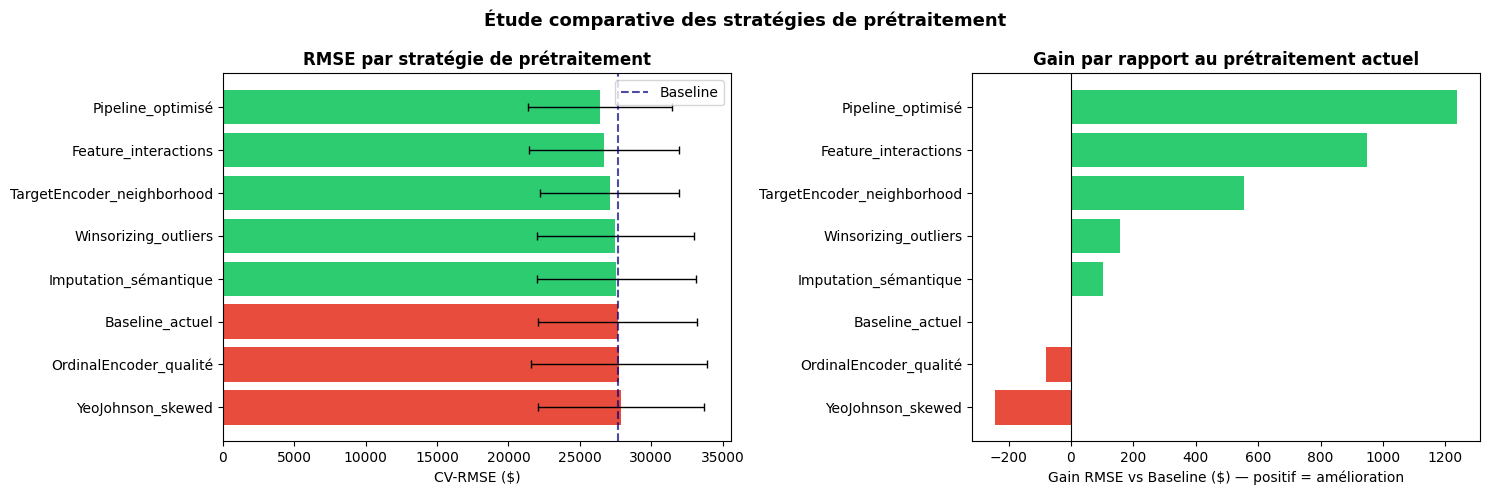

2026-06-08 12:32:19.363 | INFO     | __main__:<module>:30 - Graphique sauvegardé : reports/preprocessing_comparison.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors = ["#2ecc71" if g > 0 else "#e74c3c" for g in df_res["Gain vs Baseline ($)"]]
strategies = df_res["Stratégie"].values

# RMSE
axes[0].barh(strategies[::-1], df_res["CV-RMSE moyen ($)"].values[::-1], color=colors[::-1])
axes[0].errorbar(
    df_res["CV-RMSE moyen ($)"].values[::-1],
    range(len(strategies)),
    xerr=df_res["Std ($)"].values[::-1],
    fmt="none", color="black", capsize=3, linewidth=1
)
axes[0].axvline(results_pre["Baseline_actuel"]["mean"], color="navy", ls="--", alpha=0.7, label="Baseline")
axes[0].set_xlabel("CV-RMSE ($)")
axes[0].set_title("RMSE par stratégie de prétraitement", fontweight="bold")
axes[0].legend()

# Gain
gains = df_res["Gain vs Baseline ($)"].values
axes[1].barh(strategies[::-1], gains[::-1], color=colors[::-1])
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Gain RMSE vs Baseline ($) — positif = amélioration")
axes[1].set_title("Gain par rapport au prétraitement actuel", fontweight="bold")

plt.suptitle("Étude comparative des stratégies de prétraitement", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/preprocessing_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
logger.info("Graphique sauvegardé : reports/preprocessing_comparison.png")

## 10. Sauvegarde du meilleur pipeline

Si le pipeline optimisé est meilleur que le baseline, on l'entraîne sur tout l'ensemble d'entraînement et on sauvegarde.

In [15]:
import dill, pendulum, json as json_lib

if results_pre["Pipeline_optimisé"]["mean"] < results_pre["Baseline_actuel"]["mean"]:
    final_best = build_best_pipeline()
    final_best.fit(X_train, y_train)

    preds_te = np.expm1(final_best.predict(X_test))
    true_te  = np.expm1(y_test)
    from sklearn.metrics import mean_absolute_error, r2_score
    test_rmse = float(np.sqrt(mean_squared_error(true_te, preds_te)))
    test_r2   = float(r2_score(true_te, preds_te))
    test_mae  = float(mean_absolute_error(true_te, preds_te))

    PROJECT_DIR = Path.cwd().parent
    MODEL_DIR   = Path(PROJECT_DIR, "models")
    date_str    = pendulum.now(tz="UTC").strftime("%Y%m%d")
    model_path  = Path(MODEL_DIR, f"{date_str}_model_optimized_preprocessing.dill")
    with open(model_path, "wb") as f:
        dill.dump(final_best, f)

    # Mise à jour metrics.json
    with open(Path(PROJECT_DIR, "metrics.json"), "w") as f:
        json_lib.dump({"model": "LightGBM_optimized_preprocessing",
                       "rmse": test_rmse, "mae": test_mae, "r2": test_r2,
                       "cv_rmse": results_pre["Pipeline_optimisé"]["mean"]}, f, indent=2)

    logger.info(f"✅ Pipeline optimisé sauvegardé : {model_path}")
    logger.info(f"   Test RMSE={test_rmse:.0f}$ | MAE={test_mae:.0f}$ | R²={test_r2:.4f}")
else:
    logger.warning("Le pipeline optimisé n'améliore pas le baseline — on conserve le modèle existant")

2026-06-08 12:32:24.028 | INFO     | __main__:<module>:27 - ✅ Pipeline optimisé sauvegardé : /Users/zoro008/Documents/dic3/house_price 2/models/20260608_model_optimized_preprocessing.dill


2026-06-08 12:32:24.029 | INFO     | __main__:<module>:28 -    Test RMSE=26338$ | MAE=17058$ | R²=0.8910


---
## Synthèse

| Axe | Impact attendu | Raison |
|-----|---------------|--------|
| Imputation sémantique | Moyen | Donne de l'information structurelle au modèle |
| Outlier winsorizing | Faible-Moyen | LightGBM est robuste aux outliers |
| Yeo-Johnson | Faible | LightGBM construit des splits, moins sensible à la distribution |
| OrdinalEncoder qualité | Moyen | Préserve l'ordre naturel des notes de qualité |
| TargetEncoder neighborhood | Fort | Encode la valeur immobilière du quartier |
| Feature interactions | Variable | LightGBM peut les découvrir seul, mais aide sur petits datasets |

> *Exécuter ce notebook pour voir quelles améliorations sont réellement significatives sur vos données.*